# Chandra observation Vela X-1


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bliss import *

## 1. Load and spectra and define a results path


In [37]:
# Input spectrum
spectrum_path = Path("vela_x1_2001.dat")

# Output folder
output_dir = Path("results_vela_x1_2001")
output_dir.mkdir(exist_ok=True)

print(f"Using: {spectrum_path}")

data = np.loadtxt(spectrum_path)

e_low = data[:, 0]
e_high = data[:, 1]
values = data[:, 2]
errors = data[:, 3]
energy = 0.5 * (e_low + e_high)


# We selet an energy range
xlim = (0.5, 3)

energy_mask = (energy >= xlim[0]) & (energy <= xlim[1])

energy =energy[energy_mask]
values = values[energy_mask]
errors = errors[energy_mask]


Using: vela_x1_2001.dat


## 2. Visualize the un-binned and unfolded input spectrum

Use this cell to inspect the input spectrum before applying any rebinning or line-search procedure.

You can change `en1` and `en2` to define the energy boundaries of the region you want to visualize.

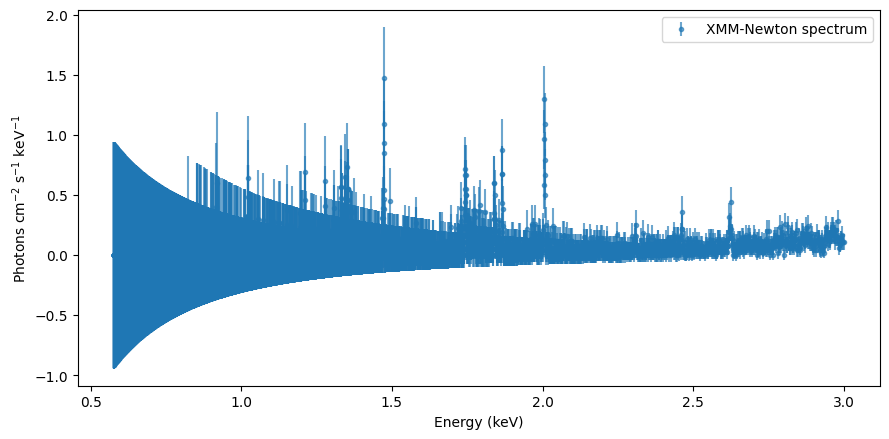

In [39]:
en1=0.5
en2=3

xlim = (en1, en2)

plot_mask = (energy >= xlim[0]) & (energy <= xlim[1])

values_plot = values[plot_mask]
errors_plot = errors[plot_mask]
energy_plot =energy[plot_mask]

plt.figure(figsize=(9, 4.5))
plt.errorbar(
    energy_plot,
    values_plot,
    
    yerr=errors_plot,
    fmt=".",
    alpha=0.65,
    label="XMM-Newton spectrum")

plt.xlabel("Energy (keV)")
plt.ylabel("Photons cm$^{-2}$ s$^{-1}$ keV$^{-1}$")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Rebin the spectra using the provided methods

The following cells show three possible rebinning strategies implemented:

- In the first cell, the spectrum is rebinned by setting the number of bins (`nbins`).
- In the second cell, the spectrum is rebinned according to a chosen energy resolution (`resolution`).
- In the third cell, the spectrum is rebinned to reach a minimum signal-to-noise ratio (`snr`) per bin.

Feel free to change these values depending on the spectral resolution and statistics required for your analysis.

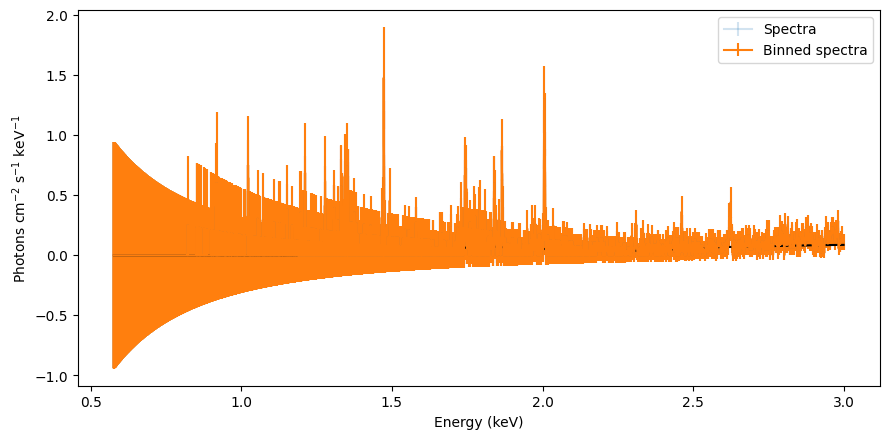

In [40]:
# Rebin by bin number
nbins=1
bin_energy, bin_values, bin_errors = rebin_bins(energy, values, errors, nbins)

baseline_bin = base_calculator(bin_values)

# Visualize
plt.figure(figsize=(9, 4.5))
plt.errorbar(energy, values, yerr=errors,alpha=0.2, label="Spectra")
plt.errorbar(bin_energy, bin_values, yerr=bin_errors, label="Binned spectra")
plt.plot(bin_energy,baseline_bin,"k")

plt.xlabel("Energy (keV)")
plt.ylabel("Photons cm$^{-2}$ s$^{-1}$ keV$^{-1}$")
plt.legend()
plt.tight_layout()
plt.show()

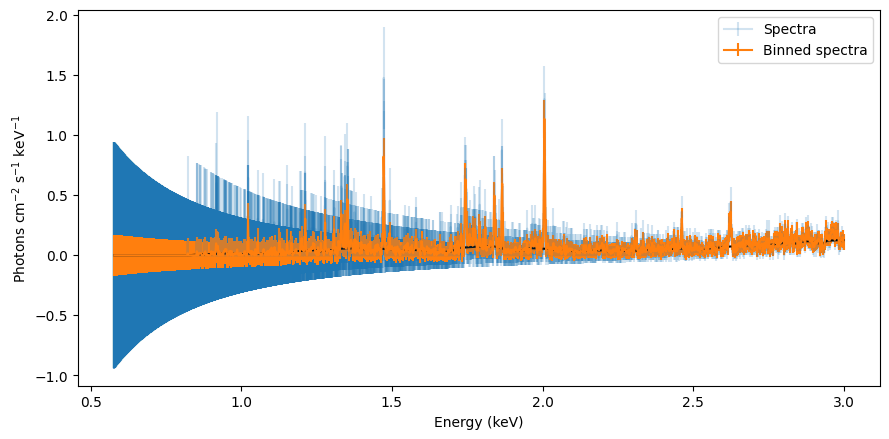

In [41]:
# Rebin by bin number
resolution=0.002
resolution_energy, resolution_values, resolution_errors = rebin_resolution(energy, values, errors, resolution)

baseline_resolution = base_calculator(resolution_values)
# Visualize
plt.figure(figsize=(9, 4.5))
plt.errorbar(energy, values, yerr=errors,alpha=0.2, label="Spectra")
plt.errorbar(resolution_energy,resolution_values, yerr=resolution_errors, label="Binned spectra")
plt.plot(resolution_energy,baseline_resolution,"k")

plt.xlabel("Energy (keV)")
plt.ylabel("Photons cm$^{-2}$ s$^{-1}$ keV$^{-1}$")
plt.legend()
plt.tight_layout()
plt.show()

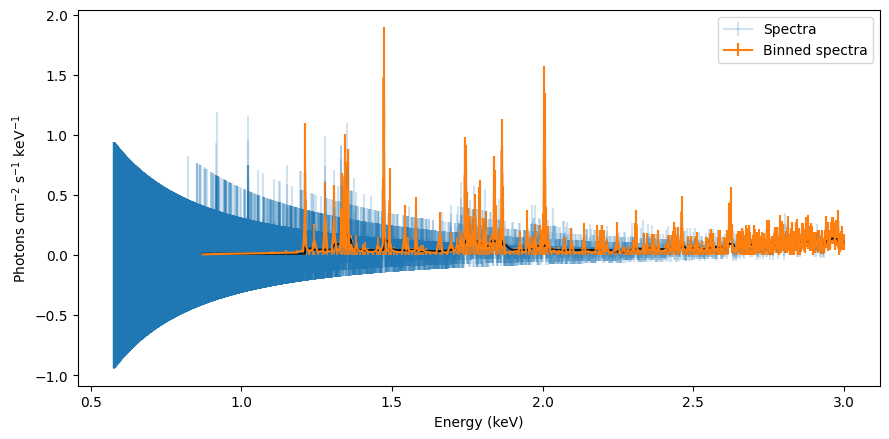

In [42]:
# Rebin by signal-to-noise
snr=1
snr_energy, snr_values, snr_errors  = rebin_snr(energy, values, errors,snr)
baseline_snr = base_calculator(snr_values)
# Visualize
plt.figure(figsize=(9, 4.5))
plt.errorbar(energy, values, yerr=errors,alpha=0.2, label="Spectra")
plt.errorbar(snr_energy,snr_values, yerr=snr_errors, label="Binned spectra")

plt.plot(snr_energy,baseline_snr,"k")

plt.xlabel("Energy (keV)")
plt.ylabel("Photons cm$^{-2}$ s$^{-1}$ keV$^{-1}$")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Run the BLiSS candidate search for each rebinning scheme

We suggest exploring different values for the signal-to-noise ratio (`snr`), number of bins (`nbins`), and energy resolution (`resolution`) used in the rebinning step, in order to assess their impact on the final result.


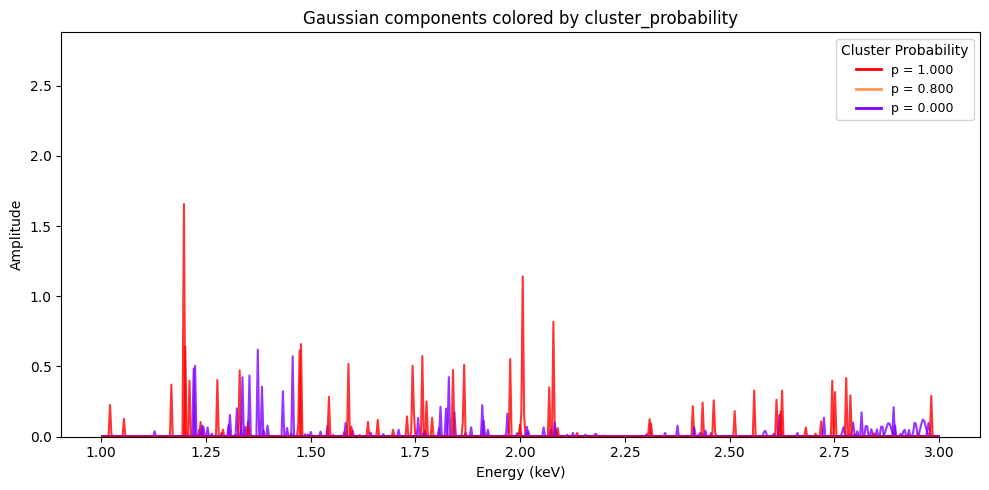

In [43]:
en1=1
en2=3

candidate_lines_bin = find_candidate_lines(
    bin_energy, bin_values, bin_errors,
    en1=en1,
    en2=en2,
    output_dir=output_dir
)
candidate_lines_bin

plot_line_prob(candidate_lines_bin)

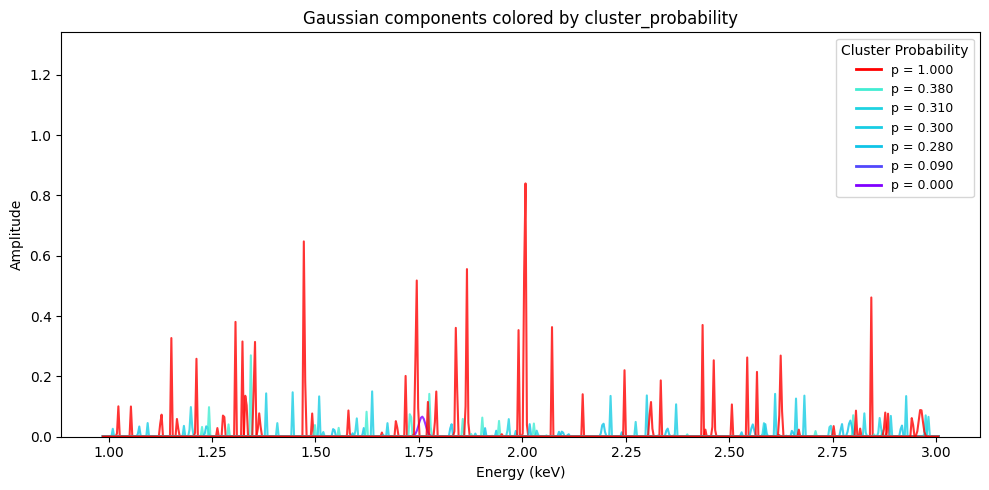

In [44]:
candidate_lines_resolution = find_candidate_lines(
    resolution_energy, resolution_values, resolution_errors,
    en1=en1,
    en2=en2,
    output_dir=output_dir,
)
candidate_lines_resolution

plot_line_prob(candidate_lines_resolution)

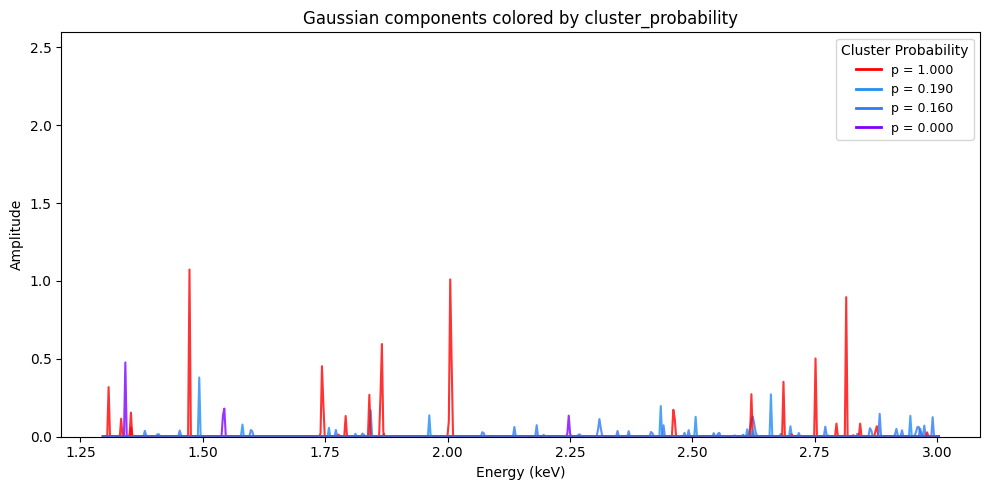

In [45]:
candidate_lines_snr = find_candidate_lines(
    snr_energy, snr_values, snr_errors,
    en1=en1,
    en2=en2,
    output_dir=output_dir,
)
candidate_lines_snr

plot_line_prob(candidate_lines_snr)

## 5. Filter line candidates and perform a global fit with tentative line classification

In this section, we use the spectrum rebinned according to the chosen signal to noise resolution.

We first filter the BLiSS line candidates using probability and significance criteria. Then, we perform a global multi-Gaussian fit to the selected candidates and provide a tentative classification of the recovered spectral lines.

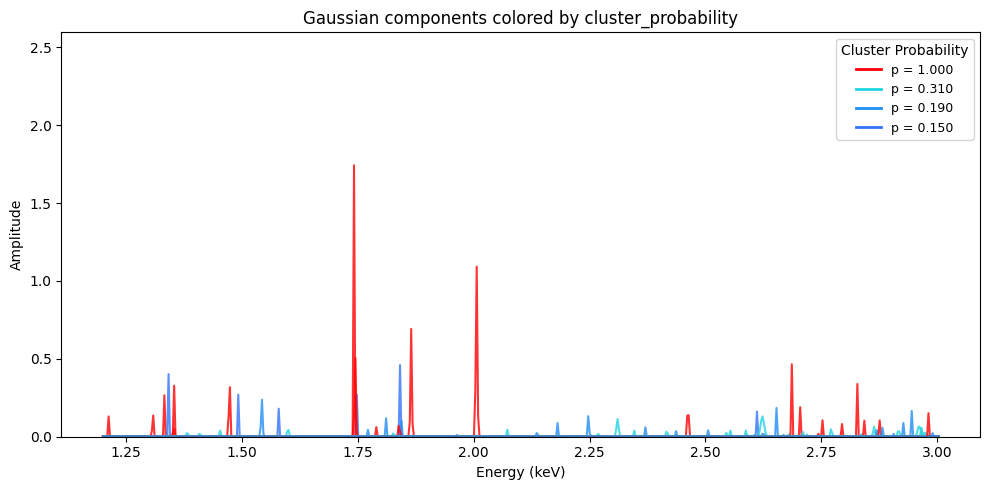

In [46]:
en1=0
en2=8

# We search for candidate lines
candidate_lines_resolution = find_candidate_lines(
    snr_energy, snr_values, snr_errors,
    en1=en1,
    en2=en2,
    output_dir=output_dir,
)
candidate_lines_resolution

plot_line_prob(candidate_lines_resolution)

## 5. Filter line candidates and perform a global fit

In this section, we use the spectrum rebinned according to the chosen energy resolution, but now over a wider energy range.

We first filter the BLiSS line candidates using probability and significance criteria. Then, we perform a global multi-Gaussian fit to the selected candidates and provide a tentative classification of the recovered spectral lines.

Because nearby emission lines may overlap or affect each other's fitted parameters, this final filtering step can provide more accurate results than treating each candidate independently. However, we caution that a physically motivated continuum model is required for a final quantitative analysis.

Feel free to modify the filtering thresholds and inspect how these choices affect the final candidate selection, line classification, and global fit.

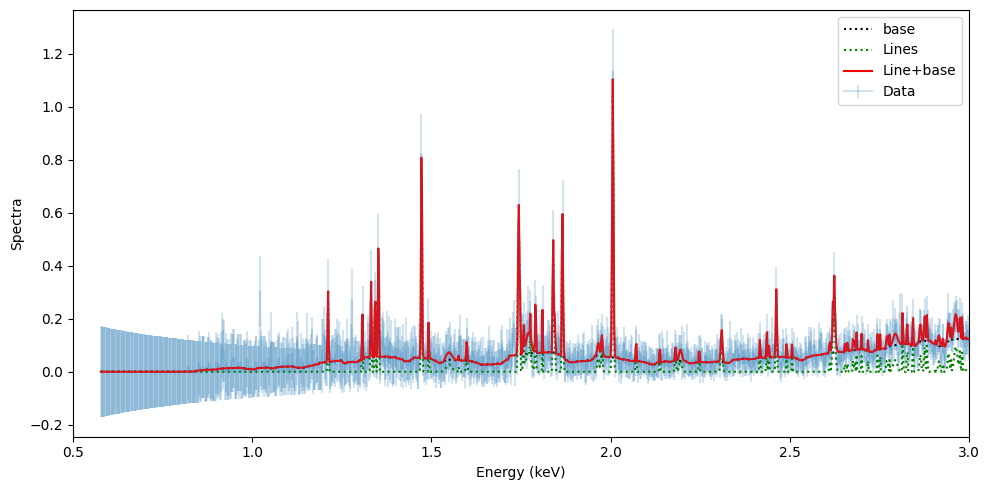

In [55]:
# ------------------------------------------------------------
# Define filtering thresholds for the BLiSS candidate-line table
# ------------------------------------------------------------

# Minimum BLiSS cluster probability (0-1)
P_MIN = 0.

# Minimum relative contribution of the candidate line (0-1)
REL_POWER_MIN = 0.

# Minimum significance thresholds. (0-Unconstrained)
# A line is kept if at least one of these SNR criteria is satisfied.
SNR_PEAK_MIN = 1.0
SNR_AREA_MIN = 1.0
SNR_AMPLITUDE_MIN = 1.0


# ------------------------------------------------------------
# Apply candidate-line selection
# ------------------------------------------------------------

lines_pd = candidate_lines_resolution

clean_mask = (
    (lines_pd["cluster_probability"] >= P_MIN)
    & (
        (lines_pd["snr_peak"] >= SNR_PEAK_MIN)
        | (lines_pd["snr_area"] >= SNR_AREA_MIN)
        | (lines_pd["snr_amplitude"] >= SNR_AMPLITUDE_MIN)
    )
    & (lines_pd["relative_power"] >= REL_POWER_MIN)
)

lines_resolution = lines_pd.loc[clean_mask].reset_index(drop=True)


# ------------------------------------------------------------
# Perform the final global multi-Gaussian fit
# ------------------------------------------------------------

lines_resolution_global = fit_global(
    lines_resolution,
    resolution_energy,
    resolution_values,
    resolution_errors,
    energy_min=0.5,
    energy_max=3,
)

## 6. Identify emission lines within a Doppler velocity window

In this section, we compare the fitted line centroids with a reference list of known emission lines.
A line is tentatively identified when its fitted energy is consistent with the expected transition energy within the chosen Doppler velocity window.

In [48]:
max_doppler_velocity =600

lines_resolution_global_ion = add_most_probable_ion(lines_resolution_global,max_doppler_velocity) 
lines_resolution_global_ion.head()

,ion,doppler_kms,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability,fit_error_flag
0,mg_vii,-592.206170,1.212061,0.000727,0.001237,0.000513,0.268863,0.122346,0.948053,0.151452,0.688739,0.018366,1.775229,2.197558,0.000834,0.000513,1.624419,22.525583,1.0,
1,mg_viii,245.381148,1.307583,0.003225,0.000839,0.003551,0.228310,1.186026,0.548705,0.133341,0.295259,0.086039,1.712219,0.192500,0.000480,0.003218,0.149264,10.889482,1.0,unconstrained
2,mg_x,-437.549815,1.331905,0.000641,0.001259,0.000506,0.292871,0.125835,0.519191,0.173101,0.379525,0.120116,1.691905,2.327419,0.000924,0.000544,1.700387,16.779699,1.0,
3,mg_xi,264.930544,1.353420,0.049398,0.000657,0.051360,0.568878,23.315911,0.511680,0.245962,0.551480,0.178145,2.312868,0.024399,0.000937,0.082698,0.011332,24.416885,1.0,unconstrained
4,mg_xi,-154.182390,1.351530,0.075965,0.000807,0.061763,0.433968,46.444260,0.462373,0.245962,0.552549,0.203139,1.764367,0.009344,0.000878,0.115538,0.007602,18.630732,1.0,unconstrained


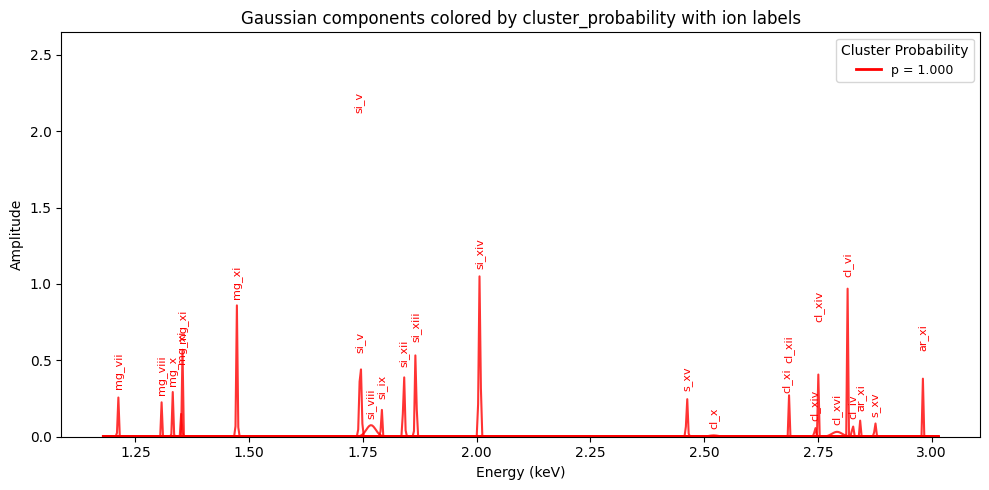

In [49]:
plot_line_prob(lines_resolution_global_ion)

#### Here, we btain a dictionary with all compatible ions in the Doppler region for each line candidate

In [50]:
dictionary_of_compatible_ions=get_all_compatible_lines(lines_resolution_global,max_doppler_velocity)
dictionary_of_compatible_ions[0].head()

,ion,energy_keV,doppler_kms
0,mg_vii,1.214460,-592.206170
1,ne_x,1.211020,257.745975
2,ne_x,1.210783,316.354221
3,fe_xxv,1.212915,-211.186368
4,fe_xxv,1.213034,-240.501539
